# Nasdaq 100 index

### Testing with ADF, SADF, GSADF and BSADF

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter # for eg. 15.000 instead of 15000 on y-axis

# api's
import yfinance as yf
from fredapi import Fred

# custom imports
%load_ext rpy2.ipython

##### 1. Download Nasdaq 100 index and CPI data from 1. jan. 1990 to 31. dec. 2025

In [3]:
# Download Nasdaq 100, ticker = "^NDX" from yahoo finance
nasdaq = yf.Ticker("^NDX")
nasdaq_data = nasdaq.history(start="1990-01-01", end="2025-12-31", interval="1mo")
nasdaq_close = nasdaq_data["Close"]
log_nasdaq_close = np.log(nasdaq_close)
nasdaq_close.index = nasdaq_close.index.tz_localize(None) # remove timezone information for easier merging with cpi data

# Download CPI data from FRED
fred = Fred(api_key="354f5cebccaba61336b2f0574d1babe2")
cpi_data = fred.get_series("CPIAUCSL", observation_start="1990-01-01", observation_end="2025-12-31")

# display 5 first rows of each dataset
print("Nasdaq 100 Close Prices:")
print(nasdaq_close.head())
print("\nCPI Data:")
print(cpi_data.head())
print(cpi_data.tail(10))

Nasdaq 100 Close Prices:
Date
1990-01-01    201.940002
1990-02-01    207.914993
1990-03-01    213.145004
1990-04-01    205.815002
1990-05-01    236.149994
Name: Close, dtype: float64

CPI Data:
1990-01-01    127.5
1990-02-01    128.0
1990-03-01    128.6
1990-04-01    128.9
1990-05-01    129.1
dtype: float64
2025-03-01    319.785
2025-04-01    320.302
2025-05-01    320.620
2025-06-01    321.435
2025-07-01    322.169
2025-08-01    323.291
2025-09-01    324.245
2025-10-01        NaN
2025-11-01    325.063
2025-12-01    326.031
dtype: float64


We now deflate the Nasdaq 100 using the CPI data

In [4]:
# deflate nasdaq by cpi
#nasdaq_deflated = nasdaq_close / cpi_data
nasdaq_deflated = (nasdaq_close / cpi_data).dropna()

# vælg base (jan 1990)
base_value = nasdaq_deflated.loc["1990-01-01"]

# indeksér til 100
nasdaq_deflated_index100 = 100 * nasdaq_deflated / base_value


# log-transformer data
log_nasdaq_deflated = np.log(nasdaq_deflated_index100)

# tjek data
nasdaq_deflated_index100.head()
#log_nasdaq_deflated.head()

Date
1990-01-01    100.000000
1990-02-01    102.556612
1990-03-01    104.645852
1990-04-01    100.811932
1990-05-01    115.491368
dtype: float64

We plot the deflated Nasdaq 100 index

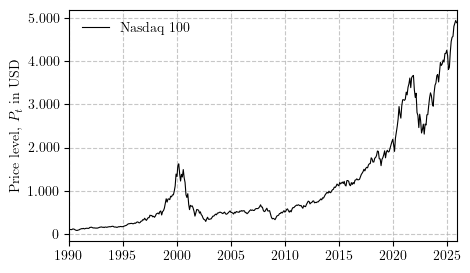

In [5]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Plot
plt.figure(figsize=(5, 3)) # size to match latex document
plt.plot(nasdaq_deflated_index100.index, nasdaq_deflated_index100, color="black", ls="-", label=r"Nasdaq 100", linewidth=0.8) 

#plt.xlabel(r"Time")
plt.ylabel(r"Price level, $P_t$ in USD")
#plt.title(r"\textbf{Nasdaq 100 Index}")

# Fix x-axis
ax = plt.gca()
ax.set_xlim(nasdaq_deflated_index100.index.min(), nasdaq_deflated_index100.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# fix y-axis to thousands seperators
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))

plt.grid(True, alpha=0.7, ls="--")
plt.legend(frameon=False, loc='upper left')

plt.savefig("plots/nasdaq100.pdf", bbox_inches="tight")
plt.show()

We could also consider marking periods with explosiveness. Rough draft is made below. 

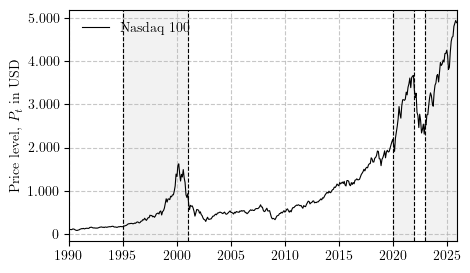

In [6]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Plot
plt.figure(figsize=(5, 3))
plt.plot(nasdaq_deflated_index100.index, nasdaq_deflated_index100, color="black", ls="-",
         label=r"Nasdaq 100", linewidth=0.8)

plt.ylabel(r"Price level, $P_t$ in USD")

ax = plt.gca()

# --------- PERIODER ---------
# Dot-com bubble
start1 = pd.Timestamp("1995-01-01")
end1   = pd.Timestamp("2001-01-01")

# Post-COVID surge
start2 = pd.Timestamp("2020-01-01")
end2   = pd.Timestamp("2022-01-01")

# AI bubble
start3 = pd.Timestamp("2023-01-01")
end3   = nasdaq_deflated_index100.index.max()

# --------- LODRETTE LINJER ---------
for date in [start1, end1, start2, end2, start3]:
    plt.axvline(date, color="black", linestyle="--", linewidth=0.8)

# --------- SHADING (anbefalet) ---------
ax.axvspan(start1, end1, alpha=0.1, color="grey")
ax.axvspan(start2, end2, alpha=0.1, color="grey")
ax.axvspan(start3, end3, alpha=0.1, color="grey")

# --------- AKSE FORMATERING ---------
ax.set_xlim(nasdaq_deflated_index100.index.min(), nasdaq_deflated_index100.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))

plt.grid(True, alpha=0.7, ls="--")
plt.legend(frameon=False, loc='upper left')

plt.savefig("plots/nasdaq_deflated_index100.pdf", bbox_inches="tight")
plt.show()

In [7]:
# download log and close as .csv
nasdaq_deflated_index100.to_csv("data/nasdaq_deflated_index100.csv")
log_nasdaq_deflated.to_csv("data/log_nasdaq_deflated_index100.csv")

##### 2. We now display results of testing Nasdaq 100 index from 1. jan. 1990 to 31. dec. 2025
Results on untransformed prices, $P_t$:

In [8]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/nasdaq_deflated_index100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y <- ts(dat[[2]])    # uses the second column of the csv file, which is the deflated index
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/nasdaq_deflated_index100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/nasdaq_deflated_index100_bsadf_cv.csv", row.names = FALSE)




── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id       adf      sadf     gsadf
  series1  2.531337  5.919062  5.919062

  gsadf_panel
     5.919062


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.40149513  1.151958  1.940131
   95  -0.04910898  1.450801  2.165954
   99   0.60887440  2.039598  2.622547



BSADF with untransformed prices, $P_t$:

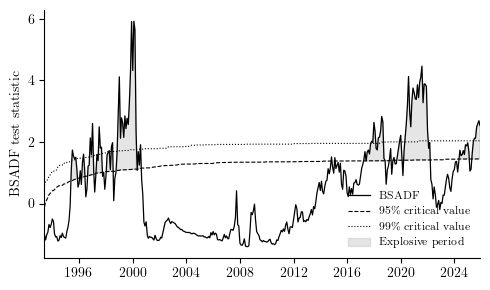

In [9]:
# font / latex style
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# load data
bsadf_stat = pd.read_csv("results/nasdaq_deflated_index100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/nasdaq_deflated_index100_bsadf_cv.csv")

t = nasdaq_deflated_index100.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))

plt.plot(t, bsadf_stat["bsadf"],
         color='black', linewidth=0.9, ls='-',
         label='BSADF')

plt.plot(t, bsadf_cv["95%"],
         color='black', linewidth=0.8, ls='--',
         label='95\\% critical value')

plt.plot(t, bsadf_cv["99%"],
         color='black', linewidth=0.8, ls=':',
         label='99\\% critical value')

plt.fill_between(t, # optional shading of explosive periods for 95% cv
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF test statistic')

# formatting
plt.tight_layout()
#plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/nasdaq_deflated_index100_bsadf.pdf", bbox_inches="tight")
plt.show()

We now examine for which periods the test statistic exceeds the critical value on the 95% confidence interval in the format of year-month-date.

In [10]:
# boolean serie: hvor BSADF > 95% kritisk værdi
is_explosive = bsadf_stat["bsadf"] > bsadf_cv["95%"]

# konverter til DataFrame med tidsindeks
df = pd.DataFrame({
    "date": t,
    "explosive": is_explosive
}).set_index("date")

# identificer start/slut på perioder
df["group"] = (df["explosive"] != df["explosive"].shift()).cumsum()

# behold kun perioder hvor explosive = True
periods = (
    df[df["explosive"]]
    .groupby("group")
    .apply(lambda x: pd.Series({
        "start": x.index.min(),
        "end": x.index.max(),
        "length": len(x)
    }))
    .reset_index(drop=True)
)

print(periods)

        start        end  length
0  1995-06-01 1995-11-01       6
1  1996-02-01 1996-02-01       1
2  1996-04-01 1996-06-01       3
3  1996-09-01 1997-02-01       6
4  1997-05-01 1997-09-01       5
5  1997-11-01 1997-11-01       1
6  1998-02-01 1998-07-01       6
7  1998-11-01 2000-04-01      18
8  2000-06-01 2000-08-01       3
9  2014-11-01 2014-11-01       1
10 2015-02-01 2015-02-01       1
11 2017-04-01 2017-05-01       2
12 2017-07-01 2018-11-01      17
13 2019-03-01 2019-04-01       2
14 2019-07-01 2019-07-01       1
15 2019-10-01 2020-02-01       5
16 2020-04-01 2022-03-01      24
17 2024-06-01 2025-02-01       9
18 2025-05-01 2025-12-01       7


/var/folders/q8/8mwdlsqx1fl6m13c32p9l0hw0000gn/T/ipykernel_25510/931205393.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


Results on transformed prices, $\ln(P_t)$:

In [11]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/log_nasdaq_deflated_index100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat[[2]])     # uses the second column of the csv file, which is the deflated index
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/log_nasdaq_deflated_index100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/log_nasdaq_deflated_index100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 41, lag = 0) ───────────────────────────────────────────────────

       id         adf      sadf     gsadf
  series1  -0.6736628  2.179838  2.544846

  gsadf_panel
     2.544846


── Monte Carlo (minw = 41, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.40149513  1.151958  1.940131
   95  -0.04910898  1.450801  2.165954
   99   0.60887440  2.039598  2.622547



BSADF with transformed prices, $\ln(P_t)$:

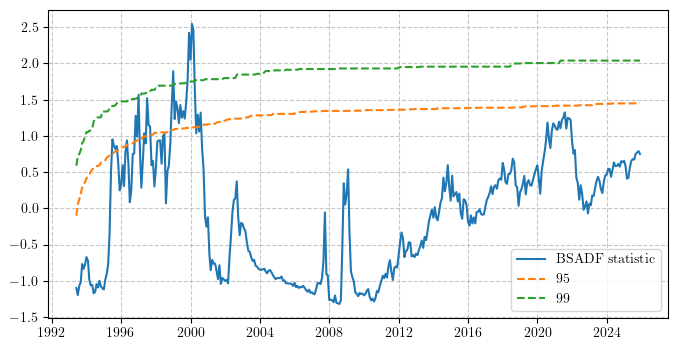

In [12]:
bsadf_stat = pd.read_csv("results/log_nasdaq_deflated_index100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/log_nasdaq_deflated_index100_bsadf_cv.csv")

t = nasdaq_deflated_index100.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/log_nasdaq_deflated_index100_bsadf.pdf", bbox_inches="tight")
plt.show()

## From 2015

##### 1. Download Nasdaq 100 index from 1. jan. 2015 to 31. dec. 2025

In [13]:
# Download Nasdaq 100, ticker = "^NDX" from yahoo finance
nasdaq = yf.Ticker("^NDX")
nasdaq_data = nasdaq.history(start="2015-01-01", end="2025-12-31", interval="1mo")
nasdaq_close = nasdaq_data["Close"]
log_nasdaq_close = np.log(nasdaq_close)
nasdaq_close.index = nasdaq_close.index.tz_localize(None) # remove timezone information for easier merging with cpi data

# Download CPI data from FRED
fred = Fred(api_key="354f5cebccaba61336b2f0574d1babe2")
cpi_data = fred.get_series("CPIAUCSL", observation_start="2015-01-01", observation_end="2025-12-31")

We now deflate the Nasdaq 100 using the CPI data

In [14]:
# deflate nasdaq by cpi
nasdaq_deflated = (nasdaq_close / cpi_data).dropna()

# vælg base (jan 2015)
base_value = nasdaq_deflated.loc["2015-01-01"]

# indeksér til 100
nasdaq_deflated_index100 = 100 * nasdaq_deflated / base_value

# log-transformer data
log_nasdaq_deflated_index100 = np.log(nasdaq_deflated_index100)

# tjek data
nasdaq_deflated_index100.head()
#log_nasdaq_deflated.head()

Date
2015-01-01    100.000000
2015-02-01    106.773952
2015-03-01    103.921706
2015-04-01    105.743298
2015-05-01    107.640097
dtype: float64

We plot the deflated Nasdaq 100 index

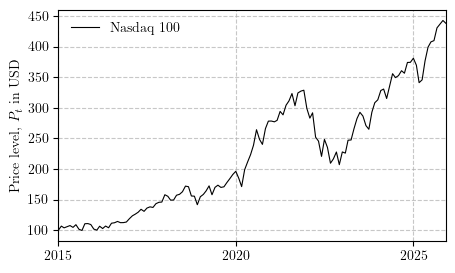

In [15]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# Plot
plt.figure(figsize=(5, 3)) # size to match latex document
plt.plot(nasdaq_deflated_index100.index, nasdaq_deflated_index100, color="black", ls="-", label=r"Nasdaq 100", linewidth=0.8) 

#plt.xlabel(r"Time")
plt.ylabel(r"Price level, $P_t$ in USD")
#plt.title(r"\textbf{Nasdaq 100 Index}")

# Fix x-axis
ax = plt.gca()
ax.set_xlim(nasdaq_deflated_index100.index.min(), nasdaq_deflated_index100.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# fix y-axis to thousands seperators
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))

plt.grid(True, alpha=0.7, ls="--")
plt.legend(frameon=False, loc='upper left')

plt.savefig("plots/nasdaq100.pdf", bbox_inches="tight")
plt.show()

In [16]:
# download log and close as .csv
nasdaq_deflated_index100.to_csv("data/2015_nasdaq_deflated_index100.csv")
log_nasdaq_deflated_index100.to_csv("data/2015_log_nasdaq_deflated_index100.csv")

##### 2. We now display results of testing Nasdaq 100 index from 1. jan. 2015 to 31. dec. 2025
Results on untransformed prices, $P_t$:

In [17]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/2015_nasdaq_deflated_index100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat[[2]])     # uses the second column of the csv file, which is the deflated index
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/2015_nasdaq_deflated_index100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/2015_nasdaq_deflated_index100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 21, lag = 0) ───────────────────────────────────────────────────

       id        adf      sadf     gsadf
  series1  0.4589704  2.006826  2.116155

  gsadf_panel
     2.116155


── Monte Carlo (minw = 21, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4367860  1.009363  1.801304
   95  -0.1087879  1.337252  2.084454
   99   0.6117711  1.930532  2.710711



BSADF with untransformed prices, $P_t$:

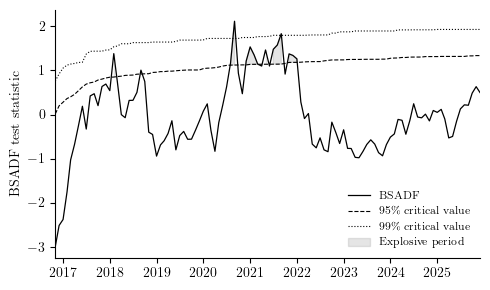

In [18]:
# font / latex style
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# load data
bsadf_stat = pd.read_csv("results/2015_nasdaq_deflated_index100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/2015_nasdaq_deflated_index100_bsadf_cv.csv")

t = nasdaq_close.index[-len(bsadf_stat):]

# plot
plt.figure(figsize=(5, 3))

plt.plot(t, bsadf_stat["bsadf"],
         color='black', linewidth=0.9, ls='-',
         label='BSADF')

plt.plot(t, bsadf_cv["95%"],
         color='black', linewidth=0.8, ls='--',
         label='95\\% critical value')

plt.plot(t, bsadf_cv["99%"],
         color='black', linewidth=0.8, ls=':',
         label='99\\% critical value')

# shading (eksplosive perioder)
plt.fill_between(t,
                 bsadf_stat["bsadf"],
                 bsadf_cv["95%"],
                 where=(bsadf_stat["bsadf"] > bsadf_cv["95%"]),
                 color='grey',
                 alpha=0.2,
                 label='Explosive period')

# labels
plt.ylabel('BSADF test statistic')

# formatting
plt.tight_layout()
#plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='lower right', fontsize=8)

plt.xlim(t.min(), t.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save
plt.savefig("plots/2015_nasdaq_deflated_index100_bsadf.pdf", bbox_inches="tight")
plt.show()

Results on transformed prices, $\ln(P_t)$:

In [111]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('data/2015_log_nasdaq_deflated_index100.csv') #../../data/simulated/timeseries/P_late_bubble.csv
y   <- ts(dat[[2]])     # uses the second column of the csv file, which is the deflated index
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "results/2015_log_nasdaq_deflated_index100_bsadf_stat.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "results/2015_log_nasdaq_deflated_index100_bsadf_cv.csv", row.names = FALSE)


── radf (minw = 21, lag = 0) ───────────────────────────────────────────────────

       id         adf       sadf      gsadf
  series1  -0.4840127  0.7637451  0.9652912

  gsadf_panel
    0.9652912


── Monte Carlo (minw = 21, nrep = 2000) ────────────────────────────────────────

  sig         adf      sadf     gsadf
   90  -0.4367860  1.009363  1.801304
   95  -0.1087879  1.337252  2.084454
   99   0.6117711  1.930532  2.710711



BSADF with transformed prices, $\ln(P_t)$:

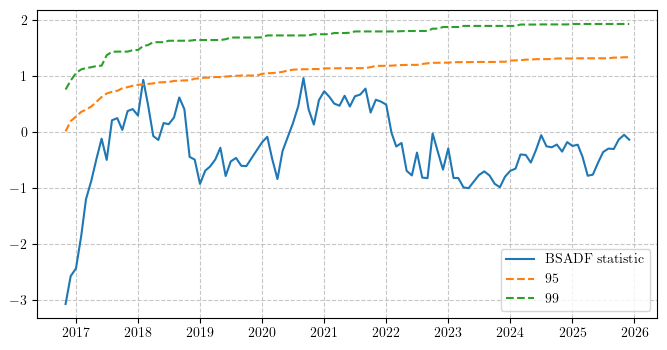

In [112]:
bsadf_stat = pd.read_csv("results/2015_log_nasdaq_deflated_index100_bsadf_stat.csv")
bsadf_cv   = pd.read_csv("results/2015_log_nasdaq_deflated_index100_bsadf_cv.csv")

t = log_nasdaq_close.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.savefig("plots/2015_log_nasdaq_deflated_index100_bsadf.pdf", bbox_inches="tight")
plt.show()